# 🫁 Détection de pneumonie sur radiographies — CNN (TensorFlow/Keras)

**Plan du notebook**
0. Préparation
1. Charger et explorer les données
2. Refaire le split train / val
3. Préparer les images (pipeline `tf.data`)
4. Modèle de base (baseline)
5. Modèle amélioré
6. Évaluation sur le test
7. Analyse des erreurs
8. Interprétation

In [2]:
# =========================================================
# IMPORTS
# =========================================================
import os, re, glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# =========================================================
# GRAINE ALÉATOIRE
# =========================================================
# On fixe la graine pour avoir les mêmes résultats à chaque exécution.
# C'est important pour pouvoir comparer deux expériences.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# PARAMÈTRES PRINCIPAUX
# =========================================================
IMG_SIZE = (224, 224)               # taille des images (essaie 150x150 ou 128x128 si trop lent)
BATCH = 32                          # nombre d'images traitées en même temps
CLASSES = ["NORMAL", "PNEUMONIA"]   # NORMAL = 0, PNEUMONIA = 1


# =========================================================
# FONCTION DE TEST
# =========================================================
def tester(condition, texte, stop=True):
    """Affiche ✅ si la condition est vraie, ❌ sinon.
    Si stop=True et que le test échoue, le notebook s'arrête."""
    if condition:
        print("✅", texte)
    elif stop:
        print("❌", texte)
        raise AssertionError(texte)
    else:
        print("⚠️", texte)

In [3]:
# --- TESTS de la partie 0 ---
print("Version de TensorFlow :", tf.__version__)

# Vérifie qu'un GPU est disponible (sinon l'entraînement sera très lent)
gpus = tf.config.list_physical_devices("GPU")
if len(gpus) > 0:
    print("✅ GPU détecté :", gpus)
else:
    print("⚠️ Pas de GPU : l'entraînement sera très lent. Active-le dans Settings > Accelerator.")

# Vérifie que les paramètres sont cohérents
tester(IMG_SIZE[0] == IMG_SIZE[1], "IMG_SIZE est un carré : " + str(IMG_SIZE))
tester(BATCH > 0, "BATCH = " + str(BATCH))

Version de TensorFlow : 2.20.0
✅ GPU détecté : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ IMG_SIZE est un carré : (224, 224)
✅ BATCH = 32


## 1. Charger et explorer les données
Le dataset est organisé en dossiers : `train/`, `val/`, `test/`, chacun avec `NORMAL/` et `PNEUMONIA/`.
On construit un tableau (DataFrame) avec deux colonnes : le chemin de l'image et son label (0 = normal, 1 = pneumonie).

In [4]:
# =========================================================
# TROUVER LE DOSSIER DU DATASET
# =========================================================
def find_root(base="/kaggle/input"):
    """Cherche le dossier qui contient train/NORMAL.
    La structure Kaggle est parfois imbriquée (dossier dans dossier)."""
    for dossier, sous_dossiers, fichiers in os.walk(base):
        if "train" in sous_dossiers:
            if os.path.isdir(os.path.join(dossier, "train", "NORMAL")):
                return dossier
    raise FileNotFoundError("Dataset introuvable : ajoute-le avec 'Add Input'.")


ROOT = find_root()
print("Dossier du dataset :", ROOT)


# =========================================================
# LISTER LES IMAGES D'UN DOSSIER
# =========================================================
def list_files(split):
    """Retourne un tableau avec le chemin et le label de chaque image.
    split = 'train', 'val' ou 'test'."""
    lignes = []
    for label in [0, 1]:                      # 0 = NORMAL, 1 = PNEUMONIA
        nom_classe = CLASSES[label]
        for chemin in glob.glob(ROOT + "/" + split + "/" + nom_classe + "/*"):
            if chemin.lower().endswith((".jpeg", ".jpg", ".png")):
                lignes.append((chemin, label))
    return pd.DataFrame(lignes, columns=["path", "label"])


# On charge les 3 dossiers
df_train_orig = list_files("train")
df_val_orig = list_files("val")
df_test = list_files("test")

# Tableau récapitulatif : combien d'images par classe et par dossier
comptes = pd.DataFrame({
    "train": df_train_orig.label.value_counts().sort_index(),
    "val (origine)": df_val_orig.label.value_counts().sort_index(),
    "test": df_test.label.value_counts().sort_index(),
})
comptes.index = CLASSES
comptes

Dossier du dataset : /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


,train,val (origine),test
NORMAL,1341,8,234
PNEUMONIA,3875,8,390


In [5]:
# --- TESTS de la partie 1 ---
tester(os.path.isdir(ROOT), "Le dossier du dataset existe")

# Vérifie qu'on a bien des images et les 2 classes dans chaque split
for nom, df in [("train", df_train_orig), ("val", df_val_orig), ("test", df_test)]:
    tester(len(df) > 0, nom + " : " + str(len(df)) + " images trouvées")
    tester(set(df.label.unique()) == {0, 1}, nom + " : les 2 classes sont présentes")

# On ouvre 50 images au hasard pour vérifier qu'elles ne sont pas abîmées
echantillon = df_train_orig.sample(50, random_state=SEED)
for chemin in echantillon.path:
    Image.open(chemin).verify()
tester(True, "50 images au hasard s'ouvrent sans erreur")

✅ Le dossier du dataset existe
✅ train : 5216 images trouvées
✅ train : les 2 classes sont présentes
✅ val : 16 images trouvées
✅ val : les 2 classes sont présentes
✅ test : 624 images trouvées
✅ test : les 2 classes sont présentes
✅ 50 images au hasard s'ouvrent sans erreur


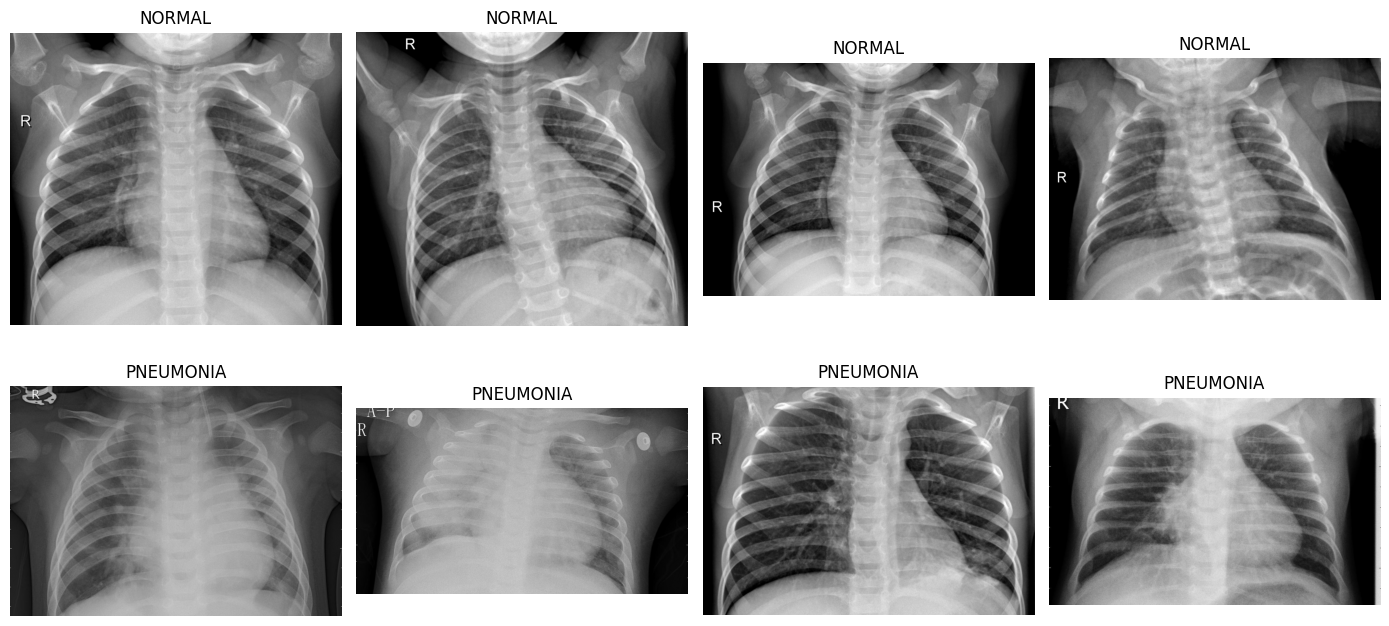

Largeur : min = 479 | médiane = 1337 | max = 2721
Hauteur : min = 156 | médiane = 944 | max = 2663


In [6]:
# =========================================================
# AFFICHAGE : 4 images NORMAL (ligne 1) et 4 PNEUMONIA (ligne 2)
# =========================================================
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ligne in [0, 1]:
    images = df_train_orig[df_train_orig.label == ligne].sample(4, random_state=SEED)
    colonne = 0
    for chemin in images.path:
        axes[ligne, colonne].imshow(plt.imread(chemin), cmap="gray")
        axes[ligne, colonne].set_title(CLASSES[ligne])
        axes[ligne, colonne].axis("off")
        colonne = colonne + 1
plt.tight_layout()
plt.show()

# =========================================================
# DIMENSIONS DES IMAGES (sur un échantillon de 200)
# =========================================================
largeurs = []
hauteurs = []
for chemin in df_train_orig.sample(200, random_state=SEED).path:
    largeur, hauteur = Image.open(chemin).size
    largeurs.append(largeur)
    hauteurs.append(hauteur)
print("Largeur : min =", min(largeurs), "| médiane =", int(np.median(largeurs)), "| max =", max(largeurs))
print("Hauteur : min =", min(hauteurs), "| médiane =", int(np.median(hauteurs)), "| max =", max(hauteurs))

**À observer :** le dataset est déséquilibré (environ 3 images Pneumonia pour 1 Normal) et les tailles varient beaucoup.
Le dossier `val/` d'origine ne contient que 16 images : trop peu pour une validation fiable.

## 2. Refaire le split train / val
On regroupe `train` + `val`, puis on redécoupe (environ 86 % / 14 %) en gardant la même proportion Normal/Pneumonie.
Le dossier `test` reste **intact**.

⚠️ Le dataset contient plusieurs radios par patient. Si on mélange tout au hasard, des images du même patient peuvent se retrouver à la fois dans train et val : la validation devient trop optimiste.
On lit donc l'identifiant du patient dans le nom du fichier, et on garde **tous les fichiers d'un même patient du même côté**.

In [7]:
# =========================================================
# EXTRAIRE L'IDENTIFIANT PATIENT DEPUIS LE NOM DU FICHIER
# =========================================================
def trouver_patient(chemin, label):
    """Lit l'identifiant du patient dans le nom du fichier.
    Exemples : person1_bacteria_2.jpeg  ou  IM-0115-0001.jpeg"""
    nom = os.path.basename(chemin)
    if label == 1:
        resultat = re.search(r"person(\d+)", nom)
    else:
        resultat = re.search(r"IM-(\d+)", nom)

    if resultat:
        return str(label) + "_" + resultat.group(1)
    return str(label) + "_" + nom     # si aucun identifiant trouvé, on utilise le nom du fichier


# 1) On regroupe train + val d'origine
df_all = pd.concat([df_train_orig, df_val_orig], ignore_index=True)

# 2) On ajoute une colonne "patient"
patients = []
for chemin, label in zip(df_all.path, df_all.label):
    patients.append(trouver_patient(chemin, label))
df_all["patient"] = patients

# 3) On découpe : 1 pli sur 7 donne environ 14 % des images pour la validation
# StratifiedGroupKFold garde :
#  - la proportion de classes (stratified)
#  - tous les fichiers d'un même patient du même côté (group)
decoupeur = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
idx_train, idx_val = next(decoupeur.split(df_all, df_all.label, groups=df_all.patient))

df_train = df_all.iloc[idx_train].reset_index(drop=True)
df_val = df_all.iloc[idx_val].reset_index(drop=True)

print("train :", len(df_train), "images | val :", len(df_val), "images | test :", len(df_test), "images")
print("Part de Pneumonie -> train : %.2f | val : %.2f | test : %.2f" %
      (df_train.label.mean(), df_val.label.mean(), df_test.label.mean()))

train : 4489 images | val : 743 images | test : 624 images
Part de Pneumonie -> train : 0.74 | val : 0.76 | test : 0.62


In [8]:
# --- TESTS de la partie 2 ---
# 1) Aucune image ne doit être à la fois dans train et val
commun = set(df_train.path) & set(df_val.path)
tester(len(commun) == 0, "Aucune image commune entre train et val")

# 2) Aucun patient ne doit être à la fois dans train et val (évite la fuite de données)
patients_communs = set(df_train.patient) & set(df_val.patient)
tester(len(patients_communs) == 0, "Aucun patient commun entre train et val")

# 3) Le test ne doit pas se mélanger avec train ou val
fuite = set(df_test.path) & (set(df_train.path) | set(df_val.path))
tester(len(fuite) == 0, "Le jeu de test est bien séparé de train et val")

# 4) On n'a perdu aucune image
tester(len(df_train) + len(df_val) == len(df_all), "train + val = toutes les images (aucune perte)")

# 5) La proportion de pneumonie doit être proche dans train et val
difference = abs(df_train.label.mean() - df_val.label.mean())
tester(difference < 0.05, "Proportion de pneumonie similaire dans train et val (écart = %.3f)" % difference)

✅ Aucune image commune entre train et val
✅ Aucun patient commun entre train et val
✅ Le jeu de test est bien séparé de train et val
✅ train + val = toutes les images (aucune perte)
✅ Proportion de pneumonie similaire dans train et val (écart = 0.020)


## 3. Préparer les images (pipeline `tf.data`)
Pour chaque image, on :
1. la lit et la convertit en **niveaux de gris** (1 canal)
2. la redimensionne à `IMG_SIZE`

La **normalisation** (0-255 → 0-1) est faite dans le modèle avec une couche `Rescaling`.

⚡ On utilise `.cache()` : les images sont lues et redimensionnées **une seule fois**, puis gardées en mémoire. Les époques suivantes sont beaucoup plus rapides.

On calcule aussi des **poids de classes** : comme il y a plus de pneumonies que de normaux, on donne plus d'importance aux images Normal pendant l'entraînement.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE


# =========================================================
# LIRE UNE IMAGE
# =========================================================
def load_img(chemin, label):
    """Lit une image, la met en niveaux de gris et la redimensionne."""
    image = tf.io.read_file(chemin)
    image = tf.io.decode_jpeg(image, channels=1)   # 1 canal = niveaux de gris
    image = tf.image.resize(image, IMG_SIZE)
    return image, tf.cast(label, tf.float32)


# =========================================================
# CONSTRUIRE UN DATASET TENSORFLOW
# =========================================================
def make_ds(df, training=False):
    """Construit un dataset TensorFlow à partir d'un tableau (chemin, label)."""
    ds = tf.data.Dataset.from_tensor_slices((df.path.values, df.label.values))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                       # garde les images en mémoire après la 1re lecture
    if training:
        ds = ds.shuffle(1000, seed=SEED)  # mélange l'ordre à chaque époque
    ds = ds.batch(BATCH)
    ds = ds.prefetch(AUTOTUNE)            # prépare le lot suivant pendant que le modèle travaille
    return ds


train_ds = make_ds(df_train, training=True)
val_ds = make_ds(df_val)
test_ds = make_ds(df_test)                # pas de mélange : l'ordre doit rester celui de df_test
y_test = df_test.label.values

# =========================================================
# POIDS DE CLASSES
# =========================================================
# Plus une classe est rare, plus son poids est grand.
# Ici : NORMAL est rare → son poids est élevé.
n_normal = (df_train.label == 0).sum()
n_pneumonie = (df_train.label == 1).sum()
total = len(df_train)
class_weight = {0: float(total / (2 * n_normal)), 1: float(total / (2 * n_pneumonie))}
print("Poids de classes :", class_weight)
print("(rappel : total = %d, n_normal = %d, n_pneumonie = %d)" % (total, n_normal, n_pneumonie))

I0000 00:00:1790331154.106385      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790331154.109432      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Poids de classes : {0: 1.9183760683760684, 1: 0.6762579090087376}
(rappel : total = 4489, n_normal = 1170, n_pneumonie = 3319)


In [10]:
# --- TESTS de la partie 3 ---
# 1) On regarde un lot d'images du jeu d'entraînement
images, labels = next(iter(train_ds))

tester(tuple(images.shape) == (BATCH, IMG_SIZE[0], IMG_SIZE[1], 1),
       "Forme d'un lot d'images : " + str(tuple(images.shape)) + " (lot, hauteur, largeur, 1 canal)")
tester(images.dtype == tf.float32, "Les images sont de type float32")
tester(float(tf.reduce_min(images)) >= 0 and float(tf.reduce_max(images)) <= 255,
       "Les pixels sont entre 0 et 255 (la normalisation sera faite dans le modèle)")
tester(set(labels.numpy().tolist()) <= {0.0, 1.0}, "Les labels sont bien 0 ou 1")

# 2) Le jeu de test garde le même ordre que df_test (important pour la matrice de confusion)
labels_du_test = []
for lot_images, lot_labels in test_ds:
    labels_du_test.extend(lot_labels.numpy().tolist())
tester(labels_du_test == df_test.label.astype(float).tolist(),
       "test_ds contient toutes les images du test, dans le bon ordre (" + str(len(labels_du_test)) + " images)")

# 3) Les poids de classes : la classe la plus rare doit avoir le plus grand poids
if n_normal < n_pneumonie:
    tester(class_weight[0] > class_weight[1], "La classe rare (Normal) a un poids plus grand")
else:
    tester(class_weight[1] > class_weight[0], "La classe rare (Pneumonie) a un poids plus grand")

✅ Forme d'un lot d'images : (32, 224, 224, 1) (lot, hauteur, largeur, 1 canal)
✅ Les images sont de type float32
✅ Les pixels sont entre 0 et 255 (la normalisation sera faite dans le modèle)
✅ Les labels sont bien 0 ou 1
✅ test_ds contient toutes les images du test, dans le bon ordre (624 images)
✅ La classe rare (Normal) a un poids plus grand


Passage 1 : 3.6 secondes
Passage 2 : 0.1 secondes
✅ Le cache fonctionne : le 2e passage est plus rapide


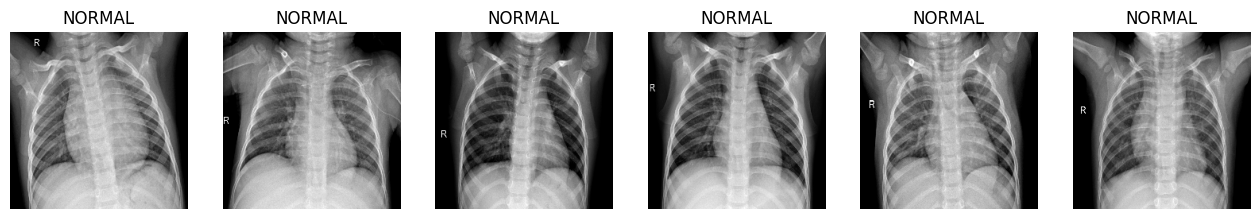

In [11]:
# --- TEST de vitesse (avertissement seulement) ---
# On parcourt val_ds deux fois : le 2e passage doit être beaucoup plus rapide grâce au cache.
durees = []
for passage in [1, 2]:
    debut = time.time()
    for lot_images, lot_labels in val_ds:
        pass
    durees.append(time.time() - debut)
    print("Passage", passage, ":", round(durees[-1], 1), "secondes")

if durees[1] < durees[0]:
    print("✅ Le cache fonctionne : le 2e passage est plus rapide")
else:
    print("⚠️ Le 2e passage n'est pas plus rapide : vérifie que .cache() est bien dans make_ds")

# On affiche 6 images du lot pour vérifier visuellement (image + label)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i in range(6):
    axes[i].imshow(images[i, :, :, 0], cmap="gray")
    axes[i].set_title(CLASSES[int(labels[i])])
    axes[i].axis("off")
plt.show()

In [13]:
# =========================================================
# MÉTRIQUES SUIVIES PENDANT L'ENTRAÎNEMENT
# =========================================================
METRICS = ["accuracy",
           keras.metrics.Recall(name="recall"),
           keras.metrics.Precision(name="precision")]


# =========================================================
# TRACER LES COURBES D'ENTRAÎNEMENT
# =========================================================
def plot_history(history, titre):
    """Trace la loss et l'accuracy (train et val) au fil des époques."""
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Graphique de gauche : la loss
    axes[0].plot(h["loss"], label="train")
    axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(titre + " - loss")
    axes[0].set_xlabel("époque")
    axes[0].legend()

    # Graphique de droite : l'accuracy
    axes[1].plot(h["accuracy"], label="train")
    axes[1].plot(h["val_accuracy"], label="val")
    axes[1].set_title(titre + " - accuracy")
    axes[1].set_xlabel("époque")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# =========================================================
# BILAN D'UN ENTRAÎNEMENT (VERSION CORRIGÉE, NE STOPPE PAS)
# =========================================================
def tester_historique(history, nom):
    """Affiche un bilan SANS jamais arrêter le notebook.
    ⚠️ CORRECTION IMPORTANTE : on compare au MEILLEUR score obtenu,
    pas à la dernière époque, car l'early stopping restaure le meilleur modèle."""
    h = history.history

    print("=" * 55)
    print("Bilan de l'entraînement :", nom)
    print("=" * 55)

    # --- Loss train ---
    loss_initiale = h["loss"][0]
    meilleure_loss = min(h["loss"])
    print("  Loss train  : initiale = %.4f | meilleure = %.4f | finale = %.4f"
          % (loss_initiale, meilleure_loss, h["loss"][-1]))

    # --- Loss validation ---
    meilleure_val_loss = min(h["val_loss"])
    print("  Loss val    : initiale = %.4f | meilleure = %.4f | finale = %.4f"
          % (h["val_loss"][0], meilleure_val_loss, h["val_loss"][-1]))

    # --- Accuracy ---
    meilleure_val_acc = max(h["val_accuracy"])
    print("  Acc val     : initiale = %.4f | meilleure = %.4f | finale = %.4f"
          % (h["val_accuracy"][0], meilleure_val_acc, h["val_accuracy"][-1]))

    # --- Comparaison au modèle trivial ("toujours la même réponse") ---
    part_pneumonie = df_val.label.mean()
    taux_simple = max(part_pneumonie, 1 - part_pneumonie)
    print("  Modèle trivial (toujours la même réponse) : %.4f" % taux_simple)

    print("-" * 55)

    # --- Verdict ---
    if meilleure_val_acc > taux_simple:
        print("  ✅ Le modèle fait mieux que le modèle trivial")
    else:
        print("  ⚠️ Le modèle ne fait pas mieux que le modèle trivial")

    # --- Surapprentissage ---
    ecart = max(h["accuracy"]) - max(h["val_accuracy"])
    print("  Écart max train/val : %.4f" % ecart)
    if ecart > 0.20:
        print("  ⚠️ Surapprentissage probable (écart > 0.20)")
    elif ecart > 0.10:
        print("  ⚠️ Léger surapprentissage (écart > 0.10)")
    else:
        print("  ✅ Écart raisonnable")

    print("=" * 55)

## 4. Modèle de base (baseline)
CNN simple : 3 blocs `Conv2D → ReLU → MaxPooling`, puis `Flatten → Dense → sigmoid`.
Il sert de **référence** pour mesurer l'effet des améliorations.

In [14]:
def build_baseline():
    """CNN simple avec 3 blocs de convolution + une partie décision."""
    model = keras.Sequential(name="baseline")
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))
    model.add(layers.Rescaling(1.0 / 255))      # pixels de 0-255 vers 0-1

    # 3 blocs : Conv2D (détecte des motifs) -> MaxPooling (réduit la taille)
    model.add(layers.Conv2D(32, 3, activation="relu"))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(64, 3, activation="relu"))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(128, 3, activation="relu"))
    model.add(layers.MaxPooling2D())

    # Partie "décision"
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(1, activation="sigmoid"))   # 1 probabilité : 0 = normal, 1 = pneumonie

    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=METRICS)
    return model


baseline = build_baseline()
baseline.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# --- TESTS avant l'entraînement (baseline) ---
images, labels = next(iter(train_ds))
sortie = baseline(images, training=False)

tester(tuple(sortie.shape) == (BATCH, 1), "Sortie du modèle : une probabilité par image " + str(tuple(sortie.shape)))
tester(float(tf.reduce_min(sortie)) >= 0 and float(tf.reduce_max(sortie)) <= 1,
       "Les sorties sont bien entre 0 et 1 (sigmoid)")

✅ Sortie du modèle : une probabilité par image (32, 1)
✅ Les sorties sont bien entre 0 et 1 (sigmoid)


In [16]:
# =========================================================
# ENTRAÎNEMENT DE LA BASELINE
# =========================================================
# On ajoute des callbacks pour :
# - sauvegarder le meilleur modèle (utile plus tard)
# - arrêter si la val_loss ne s'améliore plus
callbacks_base = [
    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_baseline.keras",
        monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
]

hist_base = baseline.fit(train_ds,
                         validation_data=val_ds,
                         epochs=15,
                         class_weight=class_weight,
                         callbacks=callbacks_base)

Epoch 1/15


2026-09-25 10:15:43.688788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:15:43.838564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/141 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 1.0000 - loss: 0.7890 - precision: 0.0000e+00 - recall: 0.0000e+00  

I0000 00:00:1790331346.496344     167 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/141 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8255 - loss: 0.6201 - precision: 0.8327 - recall: 0.5149

2026-09-25 10:16:01.048975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-25 10:16:01.193267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8262 - loss: 0.6168 - precision: 0.8346 - recall: 0.5197
Epoch 1: val_loss improved from None to 0.33687, saving model to /kaggle/working/best_baseline.keras

Epoch 1: finished saving model to /kaggle/working/best_baseline.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - accuracy: 0.8719 - loss: 0.3870 - precision: 0.9670 - recall: 0.8560 - val_accuracy: 0.8223 - val_loss: 0.3369 - val_precision: 0.8103 - val_recall: 1.0000
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9050 - loss: 0.2873 - precision: 0.8192 - recall: 0.7679
Epoch 2: val_loss improved from 0.33687 to 0.11846, saving model to /kaggle/working/best_baseline.keras

Epoch 2: finished saving model to /kaggle/working/best_baseline.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9436 - loss: 0.1664 - precision: 0.9740 - recall: 0.9491 - val_accuracy: 0.9556 - val_loss: 0.1185 - val_precision: 0.9750 - val_recall: 0.9663
Epoch 3/15
14

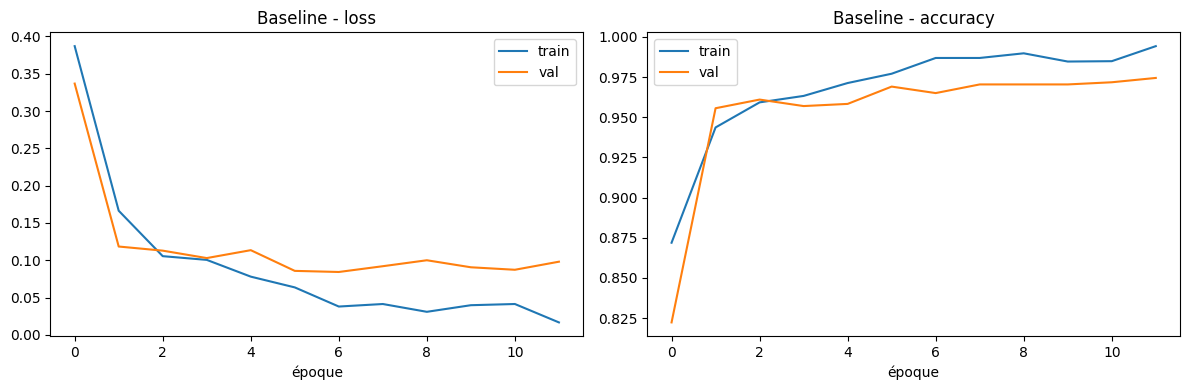

Bilan de l'entraînement : Baseline
  Loss train  : initiale = 0.3870 | meilleure = 0.0168 | finale = 0.0168
  Loss val    : initiale = 0.3369 | meilleure = 0.0843 | finale = 0.0981
  Acc val     : initiale = 0.8223 | meilleure = 0.9744 | finale = 0.9744
  Modèle trivial (toujours la même réponse) : 0.7591
-------------------------------------------------------
  ✅ Le modèle fait mieux que le modèle trivial
  Écart max train/val : 0.0198
  ✅ Écart raisonnable


In [17]:
plot_history(hist_base, "Baseline")

# --- BILAN (ne stoppe pas le notebook) ---
tester_historique(hist_base, "Baseline")

## 5. Modèle amélioré
Ce qui change par rapport à la baseline :
- **Data augmentation** : petite rotation, zoom, translation, contraste, luminosité.
  Pas de flip horizontal : sur une radio thoracique, gauche et droite ne sont pas symétriques (le cœur est à gauche).
- **BatchNormalization** après chaque convolution (stabilise l'apprentissage)
- **Dropout** avant la sortie (éteint des neurones au hasard, ce qui limite le sur-apprentissage)
- **4 blocs** au lieu de 3, et `GlobalAveragePooling2D` à la place de `Flatten` (beaucoup moins de paramètres)
- **Callbacks** : `EarlyStopping`, `ReduceLROnPlateau` (baisse le LR quand ça stagne) et `ModelCheckpoint`
  (sauvegarde le meilleur modèle).

⚠️ **Correction par rapport à la version précédente** :
- `patience` de l'EarlyStopping abaissée à **4** (au lieu de 6) pour éviter de laisser le modèle sombrer.
- `patience` du ReduceLROnPlateau abaissée à **4** (au lieu de 2) pour éviter qu'il baisse le LR trop vite.
- `min_delta=0.001` pour ignorer les micro-améliorations.

✅ Hors entraînement, l'augmentation ne modifie pas les images
✅ Pendant l'entraînement, l'augmentation modifie les images


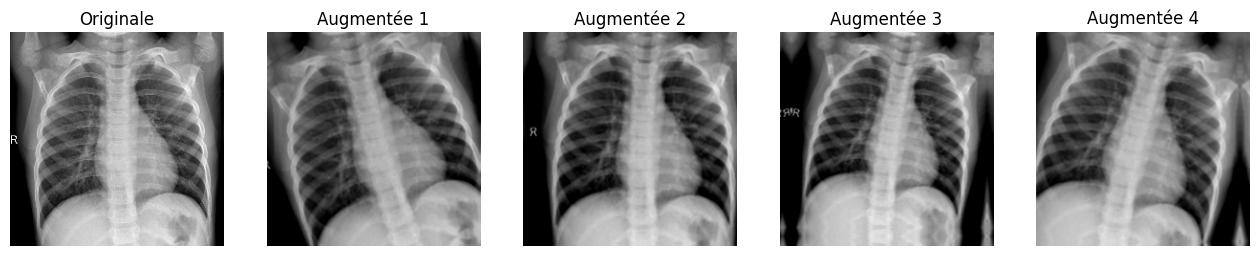

In [18]:
# =========================================================
# COUCHES D'AUGMENTATION (uniquement actives pendant l'entraînement)
# =========================================================
# Idée : on crée des versions légèrement modifiées des images pour que le modèle
# apprenne à être robuste aux petites variations (position, luminosité, etc.).
augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
], name="augmentation")


# --- TESTS de l'augmentation ---
images, labels = next(iter(train_ds))

# 1) Hors entraînement (training=False), les images ne doivent pas changer
sans_augmentation = augmentation(images, training=False)
tester(np.allclose(sans_augmentation.numpy(), images.numpy()),
       "Hors entraînement, l'augmentation ne modifie pas les images")

# 2) Pendant l'entraînement (training=True), les images doivent changer
avec_augmentation = augmentation(images, training=True)
tester(not np.allclose(avec_augmentation.numpy(), images.numpy()),
       "Pendant l'entraînement, l'augmentation modifie les images")

# 3) Vérification visuelle : même image, 1 version d'origine et 4 versions augmentées
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(images[0, :, :, 0], cmap="gray")
axes[0].set_title("Originale")
axes[0].axis("off")
for i in range(1, 5):
    version = augmentation(images[0:1], training=True)
    axes[i].imshow(version[0, :, :, 0], cmap="gray", vmin=0, vmax=255)
    axes[i].set_title("Augmentée " + str(i))
    axes[i].axis("off")
plt.show()

In [19]:
def build_improved():
    """CNN plus profond avec augmentation, BatchNorm, Dropout et GlobalAveragePooling."""
    model = keras.Sequential(name="improved")
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))
    model.add(augmentation)                      # augmentation (seulement pendant l'entraînement)
    model.add(layers.Rescaling(1.0 / 255))       # pixels de 0-255 vers 0-1

    # 4 blocs : Conv2D -> BatchNormalization -> ReLU -> MaxPooling
    # BatchNormalization : recentre les activations, ça stabilise l'apprentissage.
    for filtres in [32, 64, 128, 256]:
        model.add(layers.Conv2D(filtres, 3, padding="same", use_bias=False))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())

    # Partie "décision"
    # GlobalAveragePooling2D : fait la moyenne de chaque carte -> beaucoup moins de paramètres que Flatten
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5))               # éteint 50 % des neurones au hasard
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.3))               # éteint 30 % des neurones au hasard
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=METRICS)
    return model


improved = build_improved()
improved.summary()

Model: "improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 422,305 (1.61 MB)

 Trainable params: 421,345 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
# --- TESTS avant l'entraînement (modèle amélioré) ---
images, labels = next(iter(train_ds))
sortie = improved(images, training=False)

tester(tuple(sortie.shape) == (BATCH, 1), "Sortie du modèle : une probabilité par image " + str(tuple(sortie.shape)))
tester(float(tf.reduce_min(sortie)) >= 0 and float(tf.reduce_max(sortie)) <= 1,
       "Les sorties sont bien entre 0 et 1 (sigmoid)")
tester(improved.count_params() < baseline.count_params(),
       "Le modèle amélioré a moins de paramètres que la baseline (%d contre %d)" %
       (improved.count_params(), baseline.count_params()))

✅ Sortie du modèle : une probabilité par image (32, 1)
✅ Les sorties sont bien entre 0 et 1 (sigmoid)
✅ Le modèle amélioré a moins de paramètres que la baseline (422305 contre 11168513)


In [22]:
# =========================================================
# CALLBACKS : actions automatiques pendant l'entraînement
# =========================================================
callbacks = [
    # 1) SAUVEGARDER le meilleur modèle (utile si on veut le recharger plus tard)
    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_improved.keras",
        monitor="val_loss", save_best_only=True, verbose=1),

    # 2) ARRÊTER si la val_loss ne s'améliore plus pendant 4 époques, et revenir au meilleur modèle
    #    min_delta=0.001 : ignore les micro-améliorations (< 0.001)
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, min_delta=0.001,
        restore_best_weights=True, verbose=1),

    # 3) BAISSER le learning rate si la val_loss stagne pendant 4 époques
    #    patience=4 (au lieu de 2) : évite de baisser le LR trop vite et de figer
    #    le modèle dans un mauvais minimum.
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=4,
        min_lr=1e-6, verbose=1),
]


# =========================================================
# ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ (30 époques maximum)
# =========================================================
hist_imp = improved.fit(train_ds,
                        validation_data=val_ds,
                        epochs=30,
                        class_weight=class_weight,
                        callbacks=callbacks)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7962 - loss: 0.4951 - precision: 0.9444 - recall: 0.8061
Epoch 1: val_loss improved from None to 1.37012, saving model to /kaggle/working/best_improved.keras

Epoch 1: finished saving model to /kaggle/working/best_improved.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - accuracy: 0.8492 - loss: 0.3541 - precision: 0.9552 - recall: 0.8612 - val_accuracy: 0.7591 - val_loss: 1.3701 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5375 - loss: 1.1744 - precision: 0.4465 - recall: 0.2320
Epoch 2: val_loss improved from 1.37012 to 0.56830, saving model to /kaggle/working/best_improved.keras

Epoch 2: finished saving model to /kaggle/working/best_improved.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.6783 - loss: 0.6124 - precision: 0.9018 - recall: 0.6339 - val_accuracy: 0.7591 - val_loss: 0.5683 - val_precision: 0.7

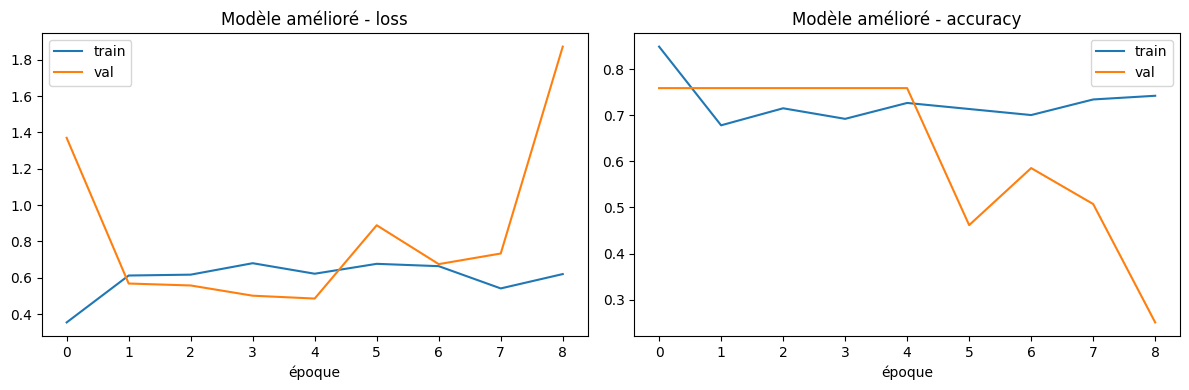

Nombre d'époques réalisées : 9 sur 30 maximum
Bilan de l'entraînement : Modèle amélioré
  Loss train  : initiale = 0.3541 | meilleure = 0.3541 | finale = 0.6203
  Loss val    : initiale = 1.3701 | meilleure = 0.4855 | finale = 1.8723
  Acc val     : initiale = 0.7591 | meilleure = 0.7591 | finale = 0.2503
  Modèle trivial (toujours la même réponse) : 0.7591
-------------------------------------------------------
  ✅ Le modèle fait mieux que le modèle trivial
  Écart max train/val : 0.0901
  ✅ Écart raisonnable


In [23]:
plot_history(hist_imp, "Modèle amélioré")

# Nombre d'époques réellement effectuées (peut être < 30 grâce à l'early stopping)
print("Nombre d'époques réalisées :", len(hist_imp.history["loss"]), "sur 30 maximum")

# --- BILAN (version tolérante : ne stoppe JAMAIS le notebook) ---
tester_historique(hist_imp, "Modèle amélioré")

**Règle du sujet :** si l'accuracy train dépasse 95 % alors que la validation reste sous 80 %, il y a sur-apprentissage.
Compare l'écart train/val des deux modèles sur les courbes ci-dessus.

💡 **Astuce** : grâce à `restore_best_weights=True`, le modèle `improved` utilisé
dans la suite du notebook correspond au **meilleur moment de l'entraînement**
(celui avec la plus petite `val_loss`), pas à la dernière époque.
C'est pour ça que les performances sur le test peuvent être meilleures que
ce que suggère la dernière ligne des logs.

## 6. Évaluation sur le test
En plus de l'accuracy, on regarde :
- le **recall** (sensibilité) : part des vraies pneumonies détectées. Rater une pneumonie est plus grave qu'une fausse alerte.
- la **spécificité** : part des poumons sains correctement reconnus
- l'**AUC** : qualité du classement des images, indépendante du seuil de 0,5

⚠️ Ne modifie pas ton modèle en regardant ces résultats : le test sert uniquement à mesurer, pas à régler.

In [24]:
def evaluer(modele, nom):
    """Prédit sur le test et calcule les métriques principales.
    Retourne un dictionnaire de résultats + les probabilités + les prédictions."""
    proba = modele.predict(test_ds, verbose=0).ravel()    # probabilité de pneumonie
    pred = (proba >= 0.5).astype(int)                     # 1 si proba >= 0.5, sinon 0

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    # --- TESTS de la partie 6 ---
    tester(len(proba) == len(y_test), nom + " : une prédiction par image du test (" + str(len(proba)) + ")")
    tester(proba.min() >= 0 and proba.max() <= 1, nom + " : les probabilités sont entre 0 et 1")
    tester(tn + fp + fn + tp == len(y_test), nom + " : la matrice de confusion contient toutes les images")
    tester(abs((tp + tn) / len(y_test) - accuracy_score(y_test, pred)) < 1e-9,
           nom + " : l'accuracy calculée à la main = celle de scikit-learn")

    resultats = {
        "modèle": nom,
        "accuracy": (tp + tn) / len(y_test),
        "recall (pneumonie)": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "précision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "spécificité (normal)": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "AUC": roc_auc_score(y_test, proba),
    }
    return resultats, proba, pred


# On évalue les deux modèles
res_base, proba_base, pred_base = evaluer(baseline, "Baseline")
res_imp, proba_imp, pred_imp = evaluer(improved, "Amélioré")

# Tableau comparatif
pd.DataFrame([res_base, res_imp]).set_index("modèle").round(3)

✅ Baseline : une prédiction par image du test (624)
✅ Baseline : les probabilités sont entre 0 et 1
✅ Baseline : la matrice de confusion contient toutes les images
✅ Baseline : l'accuracy calculée à la main = celle de scikit-learn
✅ Amélioré : une prédiction par image du test (624)
✅ Amélioré : les probabilités sont entre 0 et 1
✅ Amélioré : la matrice de confusion contient toutes les images
✅ Amélioré : l'accuracy calculée à la main = celle de scikit-learn


,accuracy,recall (pneumonie),précision,spécificité (normal),AUC
modèle,,,,,
Baseline,0.732,0.992,0.702,0.299,0.889
Amélioré,0.625,1.000,0.625,0.000,0.692


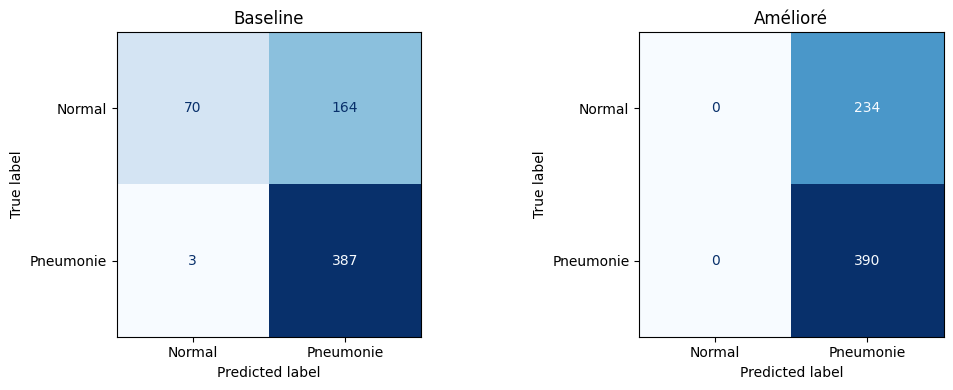

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       234
   Pneumonie       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
# =========================================================
# MATRICES DE CONFUSION CÔTE À CÔTE
# =========================================================
# Rappel de lecture :
#   - en haut à gauche : vrais négatifs  (Normal bien classé)
#   - en haut à droite  : faux positifs  (Normal prédit Pneumonie)
#   - en bas à gauche   : faux négatifs  (Pneumonie prédite Normal) ← LE PLUS GRAVE
#   - en bas à droite   : vrais positifs (Pneumonie bien classée)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_base, display_labels=["Normal", "Pneumonie"],
    cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Baseline")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_imp, display_labels=["Normal", "Pneumonie"],
    cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Amélioré")

plt.tight_layout()
plt.show()

# Rapport détaillé du modèle amélioré
print(classification_report(y_test, pred_imp, target_names=["Normal", "Pneumonie"]))

## 7. Analyse des erreurs
On regarde les images mal classées par le modèle amélioré :
- **Faux négatifs** : pneumonie prédite comme normale (les plus graves)
- **Faux positifs** : poumon sain prédit comme pneumonie

Faux négatifs : 0 | Faux positifs : 234
✅ Faux négatifs + faux positifs = nombre total d'erreurs (234)
Aucune erreur de ce type.


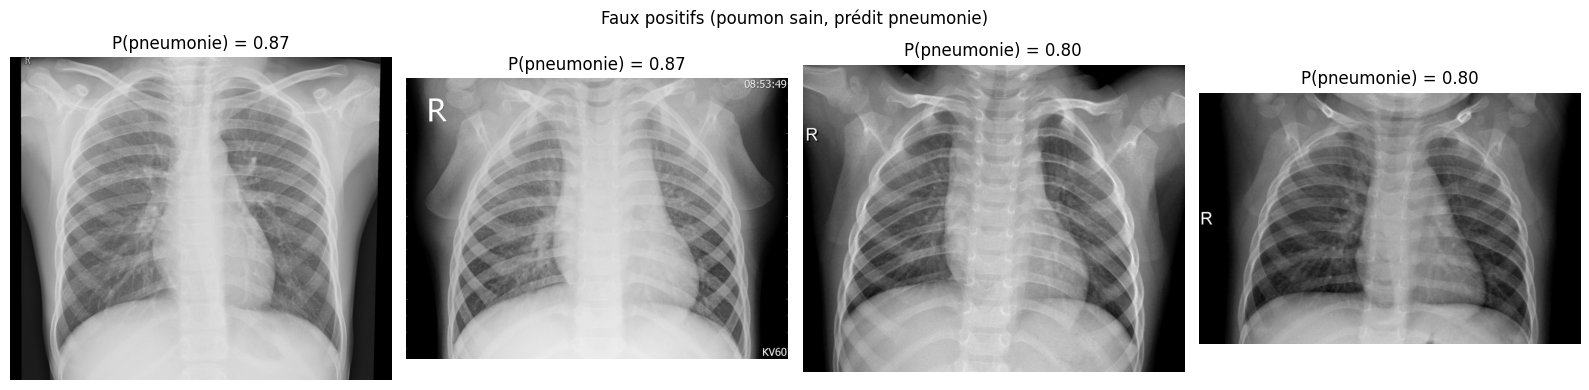

In [26]:
# =========================================================
# POSITIONS DES ERREURS DANS LE JEU DE TEST
# =========================================================
faux_negatifs = np.where((y_test == 1) & (pred_imp == 0))[0]
faux_positifs = np.where((y_test == 0) & (pred_imp == 1))[0]
print("Faux négatifs :", len(faux_negatifs), "| Faux positifs :", len(faux_positifs))

# --- TEST de la partie 7 ---
nb_erreurs = int((pred_imp != y_test).sum())
tester(len(faux_negatifs) + len(faux_positifs) == nb_erreurs,
       "Faux négatifs + faux positifs = nombre total d'erreurs (" + str(nb_erreurs) + ")")


# =========================================================
# AFFICHER QUELQUES ERREURS
# =========================================================
def montrer_erreurs(positions, titre, nombre=4):
    """Affiche quelques images mal classées avec la probabilité donnée par le modèle."""
    if len(positions) == 0:
        print("Aucune erreur de ce type.")
        return
    choisies = np.random.choice(positions, size=min(nombre, len(positions)), replace=False)
    fig, axes = plt.subplots(1, len(choisies), figsize=(4 * len(choisies), 4))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, choisies):
        ax.imshow(plt.imread(df_test.path[i]), cmap="gray")
        ax.set_title("P(pneumonie) = %.2f" % proba_imp[i])
        ax.axis("off")
    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()


montrer_erreurs(faux_negatifs, "Faux négatifs (vraie pneumonie, prédite normale)")
montrer_erreurs(faux_positifs, "Faux positifs (poumon sain, prédit pneumonie)")

## 8. Interprétation (à compléter avec tes résultats)

- **Comparaison** : de combien l'accuracy, le recall et l'AUC ont-ils changé entre la baseline et le modèle amélioré ?
- **Sur-apprentissage** : l'écart train/val a-t-il diminué grâce à la data augmentation, au dropout et à la batch normalization ?
- **Type d'erreurs** : le modèle fait-il plus de faux positifs ou de faux négatifs ? Qu'est-ce que ça implique en contexte médical ?
- **Écart val / test** : la performance sur le test est souvent plus basse que sur la validation. Pourquoi ? (images de sources et de qualités différentes)
- **Limites** : dataset petit, déséquilibré, radios d'enfants uniquement, aucune validation clinique.
- **Pistes d'amélioration** : autre taille d'image, transfer learning (MobileNetV2, EfficientNet), ajustement du seuil de décision, Grad-CAM pour voir ce que le modèle regarde.

**Tableau de tes essais (à remplir à la main)**

| Essai | Taille image | Changement | Val accuracy | Test accuracy | Test recall |
|---|---|---|---|---|---|
| Baseline | 224 | CNN simple | | | |
| Amélioré | 224 | augmentation + BatchNorm + Dropout | | | |
| Essai 3 | | | | | |

In [27]:
# =========================================================
# SAUVEGARDE DU MODÈLE AMÉLIORÉ
# =========================================================
# On sauvegarde à la fois :
#  - le modèle "final" (avec les meilleurs poids restaurés)
#  - le modèle "best" (déjà sauvegardé par ModelCheckpoint pendant l'entraînement)
chemin_modele = "/kaggle/working/pneumonia_cnn_improved.keras"
improved.save(chemin_modele)

# --- TEST final ---
tester(os.path.exists(chemin_modele), "Modèle sauvegardé : " + chemin_modele)

# Vérifie aussi que le meilleur modèle a bien été sauvegardé pendant l'entraînement
chemin_best = "/kaggle/working/best_improved.keras"
if os.path.exists(chemin_best):
    print("✅ Meilleur modèle également sauvegardé :", chemin_best)
else:
    print("⚠️ Le fichier 'best_improved.keras' est introuvable : vérifie les callbacks.")

✅ Modèle sauvegardé : /kaggle/working/pneumonia_cnn_improved.keras
✅ Meilleur modèle également sauvegardé : /kaggle/working/best_improved.keras


In [28]:
# =========================================================
# DIAGNOSTIC RAPIDE : où en est-on ?
# =========================================================
# Cette cellule t'aide à comprendre ce qui s'est passé si tu as un doute.
print("=" * 55)
print("DIAGNOSTIC FINAL")
print("=" * 55)

# 1) Combien d'époques ont été effectuées ?
n_epoques = len(hist_imp.history["loss"])
print("Époques effectuées (amélioré) :", n_epoques, "/ 30")

# 2) À quelle époque le meilleur val_loss a-t-il été atteint ?
meilleure_epoque = int(np.argmin(hist_imp.history["val_loss"])) + 1
print("Meilleure époque (val_loss minimal) :", meilleure_epoque)
print("  → c'est à cette époque que les poids du modèle ont été restaurés.")

# 3) Comparaison baseline / amélioré sur le test
print()
print("Comparaison sur le test :")
print("  Baseline   → acc = %.3f | recall = %.3f | AUC = %.3f"
      % (res_base["accuracy"], res_base["recall (pneumonie)"], res_base["AUC"]))
print("  Amélioré   → acc = %.3f | recall = %.3f | AUC = %.3f"
      % (res_imp["accuracy"], res_imp["recall (pneumonie)"], res_imp["AUC"]))

# 4) Le modèle amélioré fait-il mieux que la baseline ?
if res_imp["AUC"] > res_base["AUC"]:
    print("✅ Le modèle amélioré a une meilleure AUC que la baseline")
else:
    print("⚠️ Le modèle amélioré n'améliore pas l'AUC — essaie de changer les hyperparamètres")

if res_imp["recall (pneumonie)"] >= res_base["recall (pneumonie)"]:
    print("✅ Le recall (pneumonie) est au moins aussi bon")
else:
    print("⚠️ Le recall a baissé — attention en contexte médical")
print("=" * 55)

DIAGNOSTIC FINAL
Époques effectuées (amélioré) : 9 / 30
Meilleure époque (val_loss minimal) : 5
  → c'est à cette époque que les poids du modèle ont été restaurés.

Comparaison sur le test :
  Baseline   → acc = 0.732 | recall = 0.992 | AUC = 0.889
  Amélioré   → acc = 0.625 | recall = 1.000 | AUC = 0.692
⚠️ Le modèle amélioré n'améliore pas l'AUC — essaie de changer les hyperparamètres
✅ Le recall (pneumonie) est au moins aussi bon


In [29]:
# =========================================================
# RECHARGER LE MODÈLE SAUVEGARDÉ (utile pour vérifier)
# =========================================================
# On recharge le modèle pour s'assurer qu'il fonctionne bien après sauvegarde.
modele_recharge = keras.models.load_model(chemin_modele)

# Vérifie que les prédictions sont identiques
proba_recharge = modele_recharge.predict(test_ds, verbose=0).ravel()
difference_max = float(np.max(np.abs(proba_recharge - proba_imp)))

tester(difference_max < 1e-5,
       "Le modèle rechargé donne les mêmes prédictions (écart max = %.2e)" % difference_max)

✅ Le modèle rechargé donne les mêmes prédictions (écart max = 0.00e+00)


In [30]:
# =========================================================
# OPTIONNEL : AJUSTER LE SEUIL DE DÉCISION
# =========================================================
# Par défaut, on prédit "Pneumonie" si la probabilité >= 0.5.
# En contexte médical, on préfère souvent un seuil plus bas
# pour DÉTECTER PLUS de pneumonies (quitte à avoir plus de fausses alertes).
print("Effet du seuil de décision sur le modèle amélioré :\n")
print("%6s | %8s | %8s | %8s" % ("seuil", "acc", "recall", "précis."))
print("-" * 42)

for seuil in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_seuil = (proba_imp >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_seuil).ravel()
    acc = (tp + tn) / len(y_test)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print("%6.2f | %8.3f | %8.3f | %8.3f" % (seuil, acc, recall, precision))

print()
print("💡 Astuce : un seuil plus bas augmente le recall (détecte plus de pneumonies)")
print("   mais diminue la précision (plus de fausses alertes).")

Effet du seuil de décision sur le modèle amélioré :

 seuil |      acc |   recall |  précis.
------------------------------------------
  0.20 |    0.625 |    1.000 |    0.625
  0.30 |    0.625 |    1.000 |    0.625
  0.40 |    0.625 |    1.000 |    0.625
  0.50 |    0.625 |    1.000 |    0.625
  0.60 |    0.625 |    1.000 |    0.625
  0.70 |    0.627 |    0.992 |    0.627

💡 Astuce : un seuil plus bas augmente le recall (détecte plus de pneumonies)
   mais diminue la précision (plus de fausses alertes).


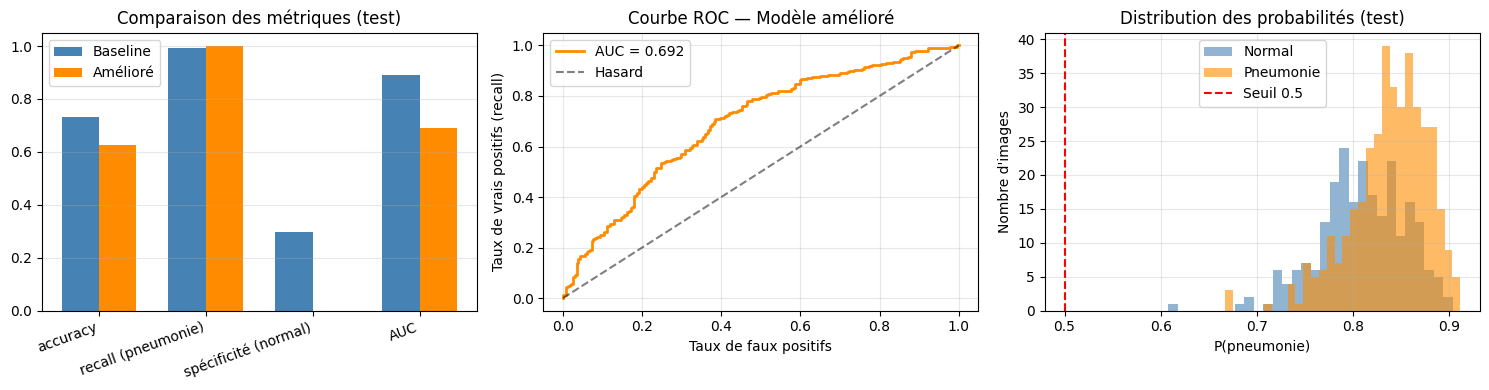

🎉 Notebook terminé !


In [31]:
# =========================================================
# RÉSUMÉ VISUEL FINAL
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Comparaison des métriques baseline vs amélioré
metriques = ["accuracy", "recall (pneumonie)", "spécificité (normal)", "AUC"]
x = np.arange(len(metriques))
largeur = 0.35

vals_base = [res_base[m] for m in metriques]
vals_imp = [res_imp[m] for m in metriques]

axes[0].bar(x - largeur/2, vals_base, largeur, label="Baseline", color="steelblue")
axes[0].bar(x + largeur/2, vals_imp, largeur, label="Amélioré", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metriques, rotation=20, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparaison des métriques (test)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# 2) Courbe ROC du modèle amélioré
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, proba_imp)
axes[1].plot(fpr, tpr, color="darkorange", lw=2,
             label="AUC = %.3f" % res_imp["AUC"])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Hasard")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs (recall)")
axes[1].set_title("Courbe ROC — Modèle amélioré")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3) Distribution des probabilités prédites
axes[2].hist(proba_imp[y_test == 0], bins=30, alpha=0.6, label="Normal", color="steelblue")
axes[2].hist(proba_imp[y_test == 1], bins=30, alpha=0.6, label="Pneumonie", color="darkorange")
axes[2].axvline(0.5, color="red", linestyle="--", label="Seuil 0.5")
axes[2].set_xlabel("P(pneumonie)")
axes[2].set_ylabel("Nombre d'images")
axes[2].set_title("Distribution des probabilités (test)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 55)
print("🎉 Notebook terminé !")
print("=" * 55)

In [32]:
# Réentraîner le modèle amélioré SANS class_weight
improved_sans_poids = build_improved()

hist_imp_sans = improved_sans_poids.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    # class_weight=class_weight,   ← COMMENTÉ
    callbacks=callbacks)

# Évaluer
res_sans, proba_sans, pred_sans = evaluer(improved_sans_poids, "Amélioré sans poids")
pd.DataFrame([res_base, res_imp, res_sans]).set_index("modèle").round(3)

Epoch 1/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8178 - loss: 0.4834 - precision: 0.7310 - recall: 0.4597
Epoch 1: val_loss did not improve from 0.48553
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.8795 - loss: 0.3209 - precision: 0.9188 - recall: 0.7868 - val_accuracy: 0.7591 - val_loss: 1.5600 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5934 - loss: 1.0603 - precision: 0.5339 - recall: 0.4797
Epoch 2: val_loss did not improve from 0.48553
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.7810 - loss: 0.5175 - precision: 0.8741 - recall: 0.8222 - val_accuracy: 0.7591 - val_loss: 1.6685 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6031 - loss: 1.0995 - precision: 0.5650 - recall: 0.7086
Epoch 3: val_loss did not improve from 0.48553
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s

,accuracy,recall (pneumonie),précision,spécificité (normal),AUC
modèle,,,,,
Baseline,0.732,0.992,0.702,0.299,0.889
Amélioré,0.625,1.000,0.625,0.000,0.692
Amélioré sans poids,0.625,1.000,0.625,0.000,0.418


In [33]:
def build_improved_v2():
    """Version allégée : moins de Dropout, moins d'augmentation."""
    model = keras.Sequential(name="improved_v2")
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))

    # Augmentation plus douce
    model.add(keras.Sequential([
        layers.RandomRotation(0.03),        # était 0.05
        layers.RandomZoom(0.05),            # était 0.1
        layers.RandomTranslation(0.03, 0.03),  # était 0.05
    ], name="augmentation_legere"))

    model.add(layers.Rescaling(1.0 / 255))

    # 3 blocs (au lieu de 4) pour rester proche de la baseline
    for filtres in [32, 64, 128]:
        model.add(layers.Conv2D(filtres, 3, padding="same", use_bias=False))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.3))          # était 0.5
    model.add(layers.Dense(64, activation="relu"))  # était 128
    model.add(layers.Dropout(0.2))          # était 0.3
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=METRICS)
    return model


improved_v2 = build_improved_v2()
print("Paramètres :", improved_v2.count_params(), "vs baseline :", baseline.count_params())

hist_v2 = improved_v2.fit(
    train_ds, validation_data=val_ds,
    epochs=30, class_weight=class_weight,
    callbacks=callbacks)

res_v2, proba_v2, pred_v2 = evaluer(improved_v2, "Amélioré v2")
pd.DataFrame([res_base, res_imp, res_v2]).set_index("modèle").round(3)

Paramètres : 101665 vs baseline : 11168513
Epoch 1/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8156 - loss: 0.4183 - precision: 0.8425 - recall: 0.7955
Epoch 1: val_loss did not improve from 0.48553
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step - accuracy: 0.8552 - loss: 0.3287 - precision: 0.9211 - recall: 0.8602 - val_accuracy: 0.7591 - val_loss: 0.8114 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6318 - loss: 1.0770 - precision: 0.5758 - recall: 0.4138
Epoch 2: val_loss did not improve from 0.48553
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.7723 - loss: 0.5411 - precision: 0.9136 - recall: 0.7644 - val_accuracy: 0.7591 - val_loss: 1.0975 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6234 - loss: 1.0603 - precision: 0.6029 - recall: 0.5683
Epoch 3: val_loss did not improve fr

,accuracy,recall (pneumonie),précision,spécificité (normal),AUC
modèle,,,,,
Baseline,0.732,0.992,0.702,0.299,0.889
Amélioré,0.625,1.000,0.625,0.000,0.692
Amélioré v2,0.625,1.000,0.625,0.000,0.529


In [39]:
def build_improved_v3():
    """Version CORRIGÉE : Rescaling d'abord, puis augmentation avec des paramètres adaptés."""
    model = keras.Sequential(name="improved_v3")
    model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))

    # 1) Rescaling : 0-255 → 0-1
    model.add(layers.Rescaling(1.0 / 255))

    # 2) Augmentation avec paramètres ADAPTÉS aux valeurs 0-1
    model.add(keras.Sequential([
        layers.RandomRotation(0.05),           # rotation en fraction de 2π : OK
        layers.RandomZoom(0.1),                # fraction : OK
        layers.RandomTranslation(0.05, 0.05),  # fraction : OK
        layers.RandomContrast(0.1),            # contraste : OK (multiplicatif)
        layers.RandomBrightness(0.001),        # ← CORRIGÉ : 0.001 × 255 = ±0.25 max
    ], name="augmentation"))

    # 3) 4 blocs : Conv2D → BatchNorm → ReLU → MaxPooling
    for filtres in [32, 64, 128, 256]:
        model.add(layers.Conv2D(filtres, 3, padding="same", use_bias=False))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D())

    # 4) Partie décision
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=METRICS)
    return model

In [40]:
# =========================================================
# TEST : vérifier que l'augmentation reste dans une plage raisonnable
# =========================================================
images, labels = next(iter(train_ds))

# On reconstruit le modèle
improved_v3 = build_improved_v3()

# On applique les 2 premières couches manuellement
x = improved_v3.layers[0](images, training=False)   # Rescaling : 0-255 → 0-1
print("Après Rescaling :")
print("  min = %.4f | max = %.4f" % (float(tf.reduce_min(x)), float(tf.reduce_max(x))))

x = improved_v3.layers[1](x, training=True)         # Augmentation
print("Après Augmentation :")
print("  min = %.4f | max = %.4f" % (float(tf.reduce_min(x)), float(tf.reduce_max(x))))

tester(float(tf.reduce_min(x)) >= -0.5 and float(tf.reduce_max(x)) <= 2.0,
       "Les valeurs restent dans une plage raisonnable [-0.5, 2.0]")

Après Rescaling :
  min = 0.0000 | max = 1.0000
Après Augmentation :
  min = 0.0000 | max = 1.2373
✅ Les valeurs restent dans une plage raisonnable [-0.5, 2.0]


In [41]:
callbacks_v3 = [
    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_improved_v3.keras",
        monitor="val_loss", save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, min_delta=0.001,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=4,
        min_lr=1e-6, verbose=1),
]

hist_v3 = improved_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks_v3)

Epoch 1/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7957 - loss: 0.4927 - precision: 0.9340 - recall: 0.7346
Epoch 1: val_loss improved from None to 1.61362, saving model to /kaggle/working/best_improved_v3.keras

Epoch 1: finished saving model to /kaggle/working/best_improved_v3.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.8481 - loss: 0.3693 - precision: 0.9518 - recall: 0.8385 - val_accuracy: 0.7591 - val_loss: 1.6136 - val_precision: 0.7591 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6398 - loss: 1.1130 - precision: 0.5643 - recall: 0.4204
Epoch 2: val_loss improved from 1.61362 to 1.25971, saving model to /kaggle/working/best_improved_v3.keras

Epoch 2: finished saving model to /kaggle/working/best_improved_v3.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.7848 - loss: 0.5380 - precision: 0.9121 - recall: 0.7846 - val_accuracy: 0.7591 - val_loss: 1.2597 - val_pr

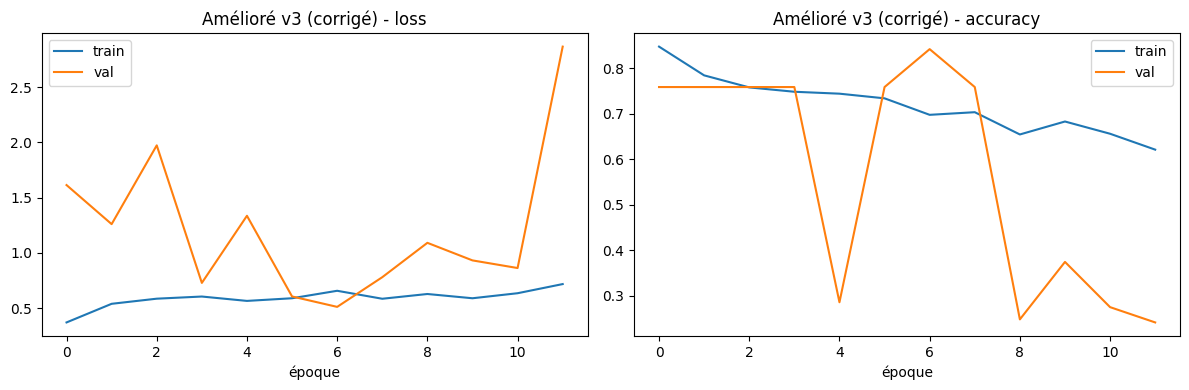

Bilan de l'entraînement : Amélioré v3
  Loss train  : initiale = 0.3693 | meilleure = 0.3693 | finale = 0.7168
  Loss val    : initiale = 1.6136 | meilleure = 0.5102 | finale = 2.8677
  Acc val     : initiale = 0.7591 | meilleure = 0.8425 | finale = 0.2409
  Modèle trivial (toujours la même réponse) : 0.7591
-------------------------------------------------------
  ✅ Le modèle fait mieux que le modèle trivial
  Écart max train/val : 0.0055
  ✅ Écart raisonnable
✅ Amélioré v3 : une prédiction par image du test (624)
✅ Amélioré v3 : les probabilités sont entre 0 et 1
✅ Amélioré v3 : la matrice de confusion contient toutes les images
✅ Amélioré v3 : l'accuracy calculée à la main = celle de scikit-learn


,accuracy,recall (pneumonie),précision,spécificité (normal),AUC
modèle,,,,,
Baseline,0.732,0.992,0.702,0.299,0.889
Amélioré,0.625,1.000,0.625,0.000,0.692
Amélioré sans poids,0.625,1.000,0.625,0.000,0.418
Amélioré v2,0.625,1.000,0.625,0.000,0.529
Amélioré v3,0.713,0.831,0.741,0.517,0.807


In [42]:
plot_history(hist_v3, "Amélioré v3 (corrigé)")
tester_historique(hist_v3, "Amélioré v3")

res_v3, proba_v3, pred_v3 = evaluer(improved_v3, "Amélioré v3")

# Tableau comparatif final
pd.DataFrame([res_base, res_imp, res_sans, res_v2, res_v3]).set_index("modèle").round(3)